# Atelier 4 — MNIST

## Imports

On importe les bibliothèques nécessaires :
- **torch** : le framework de deep learning PyTorch
- **torchvision** : fournit des datasets et transformations pour la vision (images)
- **matplotlib / numpy** : pour visualiser les images

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## Chargement du dataset MNIST

MNIST est un dataset classique de reconnaissance de chiffres manuscrits (0 à 9).
Il contient **60 000 images d'entraînement** et **10 000 images de test**, chacune en niveaux de gris de taille 28×28 pixels.

`transforms.ToTensor()` convertit les images PIL (valeurs 0–255) en tenseurs PyTorch (valeurs 0.0–1.0).

In [80]:
# Load MNIST dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Image shape:   {train_dataset[0][0].shape}")
print(f"Classes:       {train_dataset.classes}")

Train samples: 60000
Test samples:  10000
Image shape:   torch.Size([1, 28, 28])
Classes:       ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


On visualise quelques exemples pour comprendre à quoi ressemblent les données.

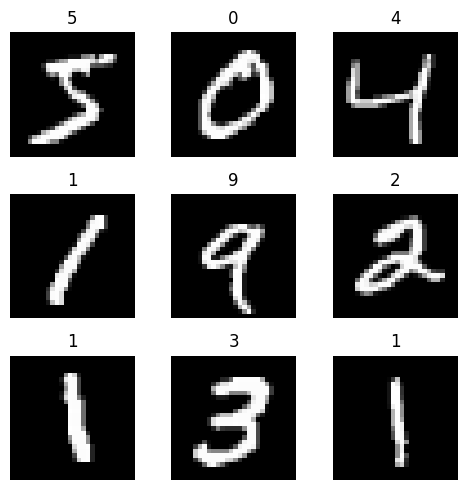

In [81]:
fig, axes = plt.subplots(3, 3, figsize=(5, 5))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

### DataLoader

Le `DataLoader` est un itérateur qui découpe le dataset en **mini-batches** et les mélange à chaque époque (`shuffle=True` pour l'entraînement).  
Ici un batch contient 64 images, chacune de forme `[1, 28, 28]` (1 canal, 28×28 pixels) → batch de forme `[64, 1, 28, 28]`.

In [82]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [83]:
train_features, train_labels = next(iter(train_dataloader))
train_features.size()

torch.Size([64, 1, 28, 28])

## Création du MLP

Un **MLP** (Multi-Layer Perceptron) est un réseau de neurones entièrement connecté.  
Chaque neurone d'une couche est relié à tous les neurones de la couche suivante.

Architecture utilisée :
```
Entrée : 784 (= 28×28 pixels aplatis)
  → Couche 1 : 128 neurones + ReLU
  → Couche 2 : 64 neurones + ReLU
  → Sortie   : 10 neurones (un score par chiffre 0–9)
```

**ReLU** (Rectified Linear Unit) est la fonction d'activation : elle vaut `max(0, x)` et permet au réseau d'apprendre des relations non-linéaires.  
**Softmax** convertit les scores de sortie en probabilités (somme = 1).

In [ ]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()          # [B, 1, 28, 28] → [B, 784]
        self.fc1 = nn.Linear(28*28, 128)     # première couche cachée
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)        # deuxième couche cachée
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)         # couche de sortie : 10 classes
        self.softmax = nn.Softmax()          # convertit en probabilités

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.softmax(x)
        return x

In [85]:
mlp = MLP()

print(mlp)

n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"\n[2.3] Paramètres entraînables : {n_params:,}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (softmax): Softmax(dim=None)
)

[2.3] Paramètres entraînables : 109,386


On vérifie que le modèle fonctionne en lui passant un tenseur aléatoire de la même forme qu'un vrai batch.

In [86]:
x_dummy = torch.randn(1, 784)
output = mlp(x_dummy)
print(f"\n[2.4] Forward pass : entrée {x_dummy.shape} -> sortie {output.shape}")
print(f"Sortie : {output}")


[2.4] Forward pass : entrée torch.Size([1, 784]) -> sortie torch.Size([1, 10])
Sortie : tensor([[0.0895, 0.1196, 0.1036, 0.0986, 0.0955, 0.0932, 0.0902, 0.0958, 0.1163,
         0.0975]], grad_fn=<SoftmaxBackward0>)


## Entraînement

L'entraînement d'un réseau de neurones repose sur deux éléments :

- **Fonction de perte** (`CrossEntropyLoss`) : mesure l'écart entre la prédiction du modèle et la vraie étiquette. L'objectif est de la minimiser.
- **Optimiseur** (`AdamW`, lr=0.001) : met à jour les poids du réseau après chaque batch en suivant le gradient de la perte. AdamW est une variante efficace de la descente de gradient.

L'entraînement alterne entre deux phases à chaque **époque** (passage complet sur le dataset) :
1. `train_loop` — le modèle apprend en ajustant ses poids
2. `test_loop` — le modèle est évalué sans mise à jour des poids (`torch.no_grad()`)

In [87]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3)

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()  # active le mode entraînement (dropout, batchnorm se comportent différemment)
    for batch, (x, y_true) in enumerate(dataloader):
        y_pred = model(x)
        loss = loss_fn(y_pred, y_true)

        # Rétropropagation : calcule les gradients puis met à jour les poids
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()  # remet les gradients à zéro pour le prochain batch

        if batch % 100 == 0:
            loss, current = loss.item(), batch * 64 + len(x)
            print(f"loss : {loss:.4f} [{current:>5d} / {size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()  # désactive le mode entraînement
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():  # pas de calcul de gradients en évaluation (plus rapide)
        for x, y_true in dataloader:
            y_pred = model(x)
            test_loss += loss_fn(y_pred, y_true).item()
            # argmax(1) : prend l'indice du score le plus élevé parmi les 10 classes
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size

    print(f"Test error : Accuracy: {100 * correct:>0.1f}%, Avg loss : {test_loss:>8f}")

In [89]:
epochs = 5

for t in range(epochs):
    print("Epoch :", t+1)
    train_loop(train_dataloader, mlp, criterion, optimizer)
    test_loop(test_dataloader, mlp, criterion)

print("Done")

Epoch : 1
loss : 2.3022 [   64 / 60000]
loss : 1.6459 [ 6464 / 60000]
loss : 1.5244 [12864 / 60000]
loss : 1.5899 [19264 / 60000]
loss : 1.5190 [25664 / 60000]
loss : 1.5299 [32064 / 60000]
loss : 1.5313 [38464 / 60000]
loss : 1.6068 [44864 / 60000]
loss : 1.5455 [51264 / 60000]
loss : 1.5025 [57664 / 60000]
Test error : Accuracy: 93.42:>0.1f%, Avg loss : 1.531584
Epoch : 2
loss : 1.5232 [   64 / 60000]
loss : 1.5226 [ 6464 / 60000]
loss : 1.4982 [12864 / 60000]
loss : 1.5481 [19264 / 60000]
loss : 1.5134 [25664 / 60000]
loss : 1.5032 [32064 / 60000]
loss : 1.4795 [38464 / 60000]
loss : 1.5099 [44864 / 60000]
loss : 1.5027 [51264 / 60000]
loss : 1.5173 [57664 / 60000]
Test error : Accuracy: 94.21000000000001:>0.1f%, Avg loss : 1.521635
Epoch : 3
loss : 1.5314 [   64 / 60000]
loss : 1.5078 [ 6464 / 60000]
loss : 1.5361 [12864 / 60000]
loss : 1.4903 [19264 / 60000]
loss : 1.5258 [25664 / 60000]
loss : 1.5080 [32064 / 60000]
loss : 1.4616 [38464 / 60000]
loss : 1.4921 [44864 / 60000]
loss

On lance l'entraînement sur 5 époques. À chaque époque, on s'attend à voir la loss diminuer et l'accuracy augmenter.